# `Maranatha.jl` :: Production Run Analysis

## Configure the Numerical Experiment and Generate an External Run Script

In this workflow the heavy numerical computation is not executed directly
inside the notebook. Instead, we first define all experiment parameters
and programmatically generate a standalone Julia script that will perform
the quadrature study.

This approach is useful when:

- high thread counts are required,
- GPU or HPC resources are involved,
- long runs should be reproducible outside the notebook,
- execution logs must be preserved independently.

The generated script encodes the exact experiment configuration and can
be executed from the shell or from within the notebook.

In [51]:
using DoubleFloats

# bounds=(0.0,π)
bounds = (Double64(0.0), Double64(pi))
dim = 4
rule = :gauss_p6
boundary = :LU_EXEX
err_method = :refinement # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
nerr_terms = 3
ff_shift = 0
fit_terms = 4
result_string = "Z_q"
save_path = joinpath("../samples", "jld2")
write_summary = true
save_file=true
use_cuda=false
use_error_jet=false
real_type = Double64

ns = [3,4,5,6,7,8,9]
ns .+= 20

Nstr = join(sort(ns), "_")
run_result_file = joinpath(
    save_path,
    "result_$(result_string)_$(rule)_$(boundary)_N_$(Nstr).jld2"
)

open("07_Production_Run_Analysis.jl", "w") do io
    write(io, """
using Maranatha
using DoubleFloats

include("../scripts/experiments/integrand_Z_q.jl")

ff(x1,x2,x3,x4) = integrand_Z_q((x1,x2,x3,x4))

# bounds=(0.0,π)
bounds = $(repr(bounds))
dim = $(repr(dim))
rule = $(repr(rule))
boundary = $(repr(boundary))
err_method = $(repr(err_method))
nerr_terms = $(repr(nerr_terms))
ff_shift = $(repr(ff_shift))
fit_terms = $(repr(fit_terms))
result_string = $(repr(result_string))
save_path = $(repr(save_path))
write_summary = $(repr(write_summary))
save_file = $(repr(save_file))
use_cuda = $(repr(use_cuda))
use_error_jet = $(repr(use_error_jet))
real_type = $(repr(real_type))

ns = $(repr(ns))

Maranatha.Utils.JobLoggerTools.log_stage_benji("BEGIN run_Maranatha")

@time run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_error_jet=use_error_jet,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary,
    use_cuda=use_cuda,
)

Maranatha.Utils.JobLoggerTools.log_stage_benji("END run_Maranatha")""")
end

1026

## Execute the Production Run via External Script

We now launch the generated script using a Bash wrapper.

Running the computation externally allows us to:

- use a large number of CPU threads,
- avoid notebook kernel limitations,
- capture detailed logs,
- reproduce the run in a non-interactive environment.

This step may take substantial time depending on the dimensionality,
rule order, and sample counts.

In [52]:
N_threads=81

run(`bash 07_Production_Run_Analysis.bash $(repr(N_threads))`)

2026-03-20 14:03:32 CMD: JULIA_NUM_THREADS=81 julia --project 07_Production_Run_Analysis.jl
[2026-03-20 14:03:38.631] 
[2026-03-20 14:03:38.716] ==================================================
[2026-03-20 14:03:38.716] >>> BEGIN run_Maranatha
[2026-03-20 14:03:38.716] ==================================================
[2026-03-20 14:03:38.716] 
[2026-03-20 14:03:53.908] 
[2026-03-20 14:03:53.908] ==================================================
[2026-03-20 14:03:53.908] >>> Start run_Maranatha
[2026-03-20 14:03:53.908] ==================================================
[2026-03-20 14:03:53.908] 
[2026-03-20 14:03:57.345] Global grid: 138×138×138×138 points | threads: 81 → axis splits = [3, 3, 3, 3] → total subgrids = 81
[2026-03-20 14:04:08.423] Global grid: 276×276×276×276 points | threads: 81 → axis splits = [3, 3, 3, 3] → total subgrids = 81
[2026-03-20 14:05:59.850] Global grid: 144×144×144×144 points | threads: 81 → axis splits = [3, 3, 3, 3] → total subgrids = 81
[2026-03-20

Process(`bash 07_Production_Run_Analysis.bash 81`, ProcessExited(0))

## Load the Analysis Environment

After the external computation completes, we switch to analysis mode
inside the notebook. The `Maranatha` package is loaded to access tools
for reading result files, visualization, fitting, and reporting.

In [53]:
using Maranatha

## Load the Saved Result File

The production run produced a JLD2 file containing the datapoints and
metadata of the quadrature study.

We now load this file into memory to perform inspection, visualization,
and statistical analysis.

In [54]:
run_result = load_datapoint_results(run_result_file)

(a = 0.0, b = 3.141592653589793, nsamples = [23, 24, 25, 26, 27, 28, 29], h = [0.13659098493868665, 0.1308996938995747, 0.12566370614359174, 0.1208304866765305, 0.11635528346628864, 0.1121997376282069, 0.10833078115826873], tuple_h = [0.13659098493868665, 0.1308996938995747, 0.12566370614359174, 0.1208304866765305, 0.11635528346628864, 0.1121997376282069, 0.10833078115826873], avg = [0.773804982804424, 0.773802054187241, 0.7737994698701902, 0.7737971779270794, 0.7737951358630728, 0.7737933086328104, 0.7737916671257126], err = [(method = :gauss_refinement_difference, rule = :gauss_p6, boundary = :LU_EXEX, N_coarse = 23, N_fine = 46, dim = 4, h_coarse = 0.13659098493868665, h_fine = 0.06829549246934333, q_coarse = 0.773804982804424, q_fine = 0.7737780619486756, estimate = 2.6920855748402417e-5, signed_diff = -2.6920855748402417e-5, reference = 0.7737780619486756), (method = :gauss_refinement_difference, rule = :gauss_p6, boundary = :LU_EXEX, N_coarse = 24, N_fine = 48, dim = 4, h_coarse 

## Inspect Raw Convergence Datapoints

Before performing any fitting, it is important to examine the raw
numerical results.

This plot shows how the estimated integral values vary with resolution,
allowing us to detect anomalies, saturation effects, or deviations from
the expected asymptotic regime.

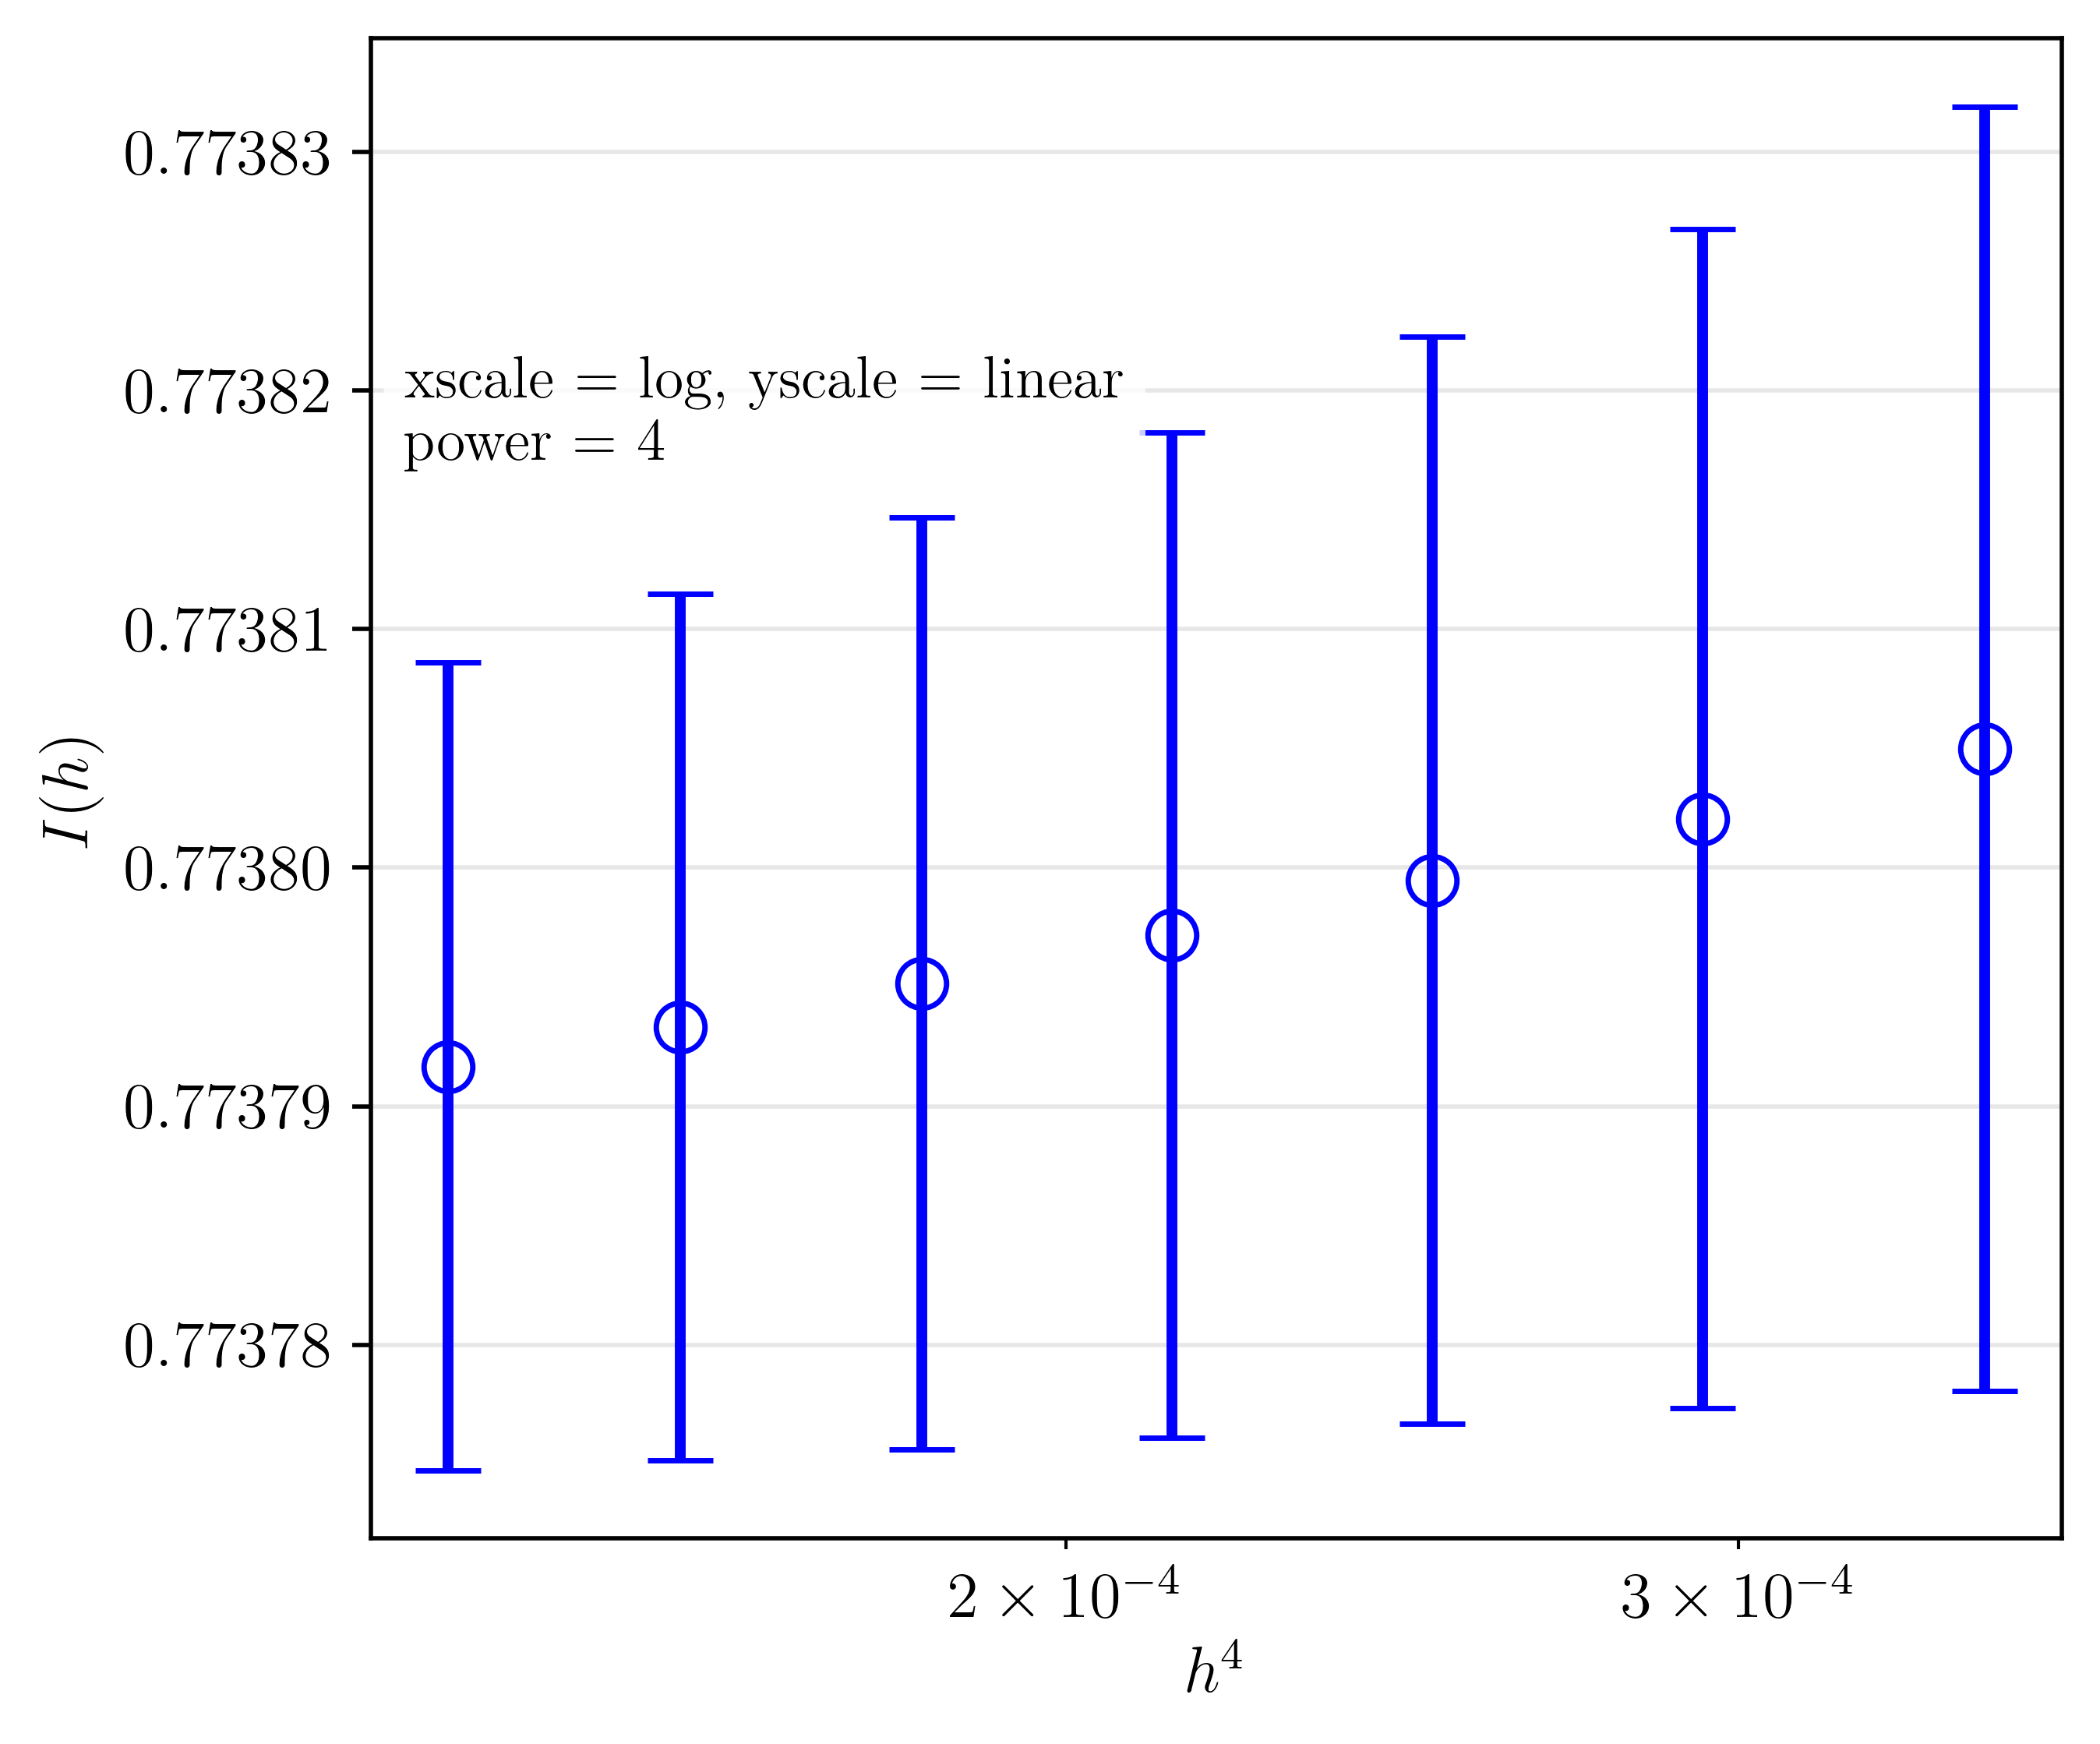

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_gauss_p6_LU_EXEX_datapoints_hpow_4_log_linear-crop.pdf'.


In [55]:
h_power = 4
xscale = :log
yscale = :linear

plot_datapoints_result(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    figs_dir = save_path,
    save_file = true
)

## Generate a Datapoints-Only Internal Note

We can produce a standalone report documenting the raw convergence data
without any model assumptions or extrapolation.

Such notes are useful for:

- archival purposes,
- debugging numerical behavior,
- sharing preliminary results,
- verifying dataset integrity before fitting.

In [56]:
note_info = write_convergence_internal_note_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode

(./inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_
linear.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benjamin/w

(note_dir = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear", figs_dir = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear/figs", summary_tex_path = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear_table.tex", fig_tex_path = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear_figs.tex", master_tex_path = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear.tex", makefile_path = "../samples/jld2/inote_summary_result_Z_q_gauss_p6_LU_EXEX_N_23_24_25_26_27_28_29_hpow_4_log_linear/Makefile", moved_plots = ["../samp

## Perform Least-Chi-Square Extrapolation

We now estimate the continuum limit (h → 0) using a weighted
least-chi-square fit based on the residual power model determined by the
quadrature rule.

The fitting procedure also produces parameter uncertainties and goodness-of-fit diagnostics.

In [57]:
fit_nterms = 2
fit_nerr_terms = 3

fit_result = least_chi_square_fit(
    run_result; 
    nterms=fit_nterms, 
    ff_shift=0, 
    nerr_terms=fit_nerr_terms
)

print_fit_result(fit_result)

[2026-03-20 14:25:34.009]            λ_0 = 0.773786(15)
[2026-03-20 14:25:34.009]            λ_1 = 0.42(56) *
[2026-03-20 14:25:34.009] 
[2026-03-20 14:25:34.009] Chi^2 / d.o.f. = 2.928370875683e-03 / 5 = 5.856741751366e-04
[2026-03-20 14:25:34.009] Result (h→0)   = 0.773786(15)
[2026-03-20 14:25:34.009] 


## Visualize the Fitted Convergence Model

This plot overlays the fitted model with the datapoints, providing a
visual assessment of:

- how well the model describes the data,
- whether the asymptotic regime has been reached,
- potential systematic deviations.

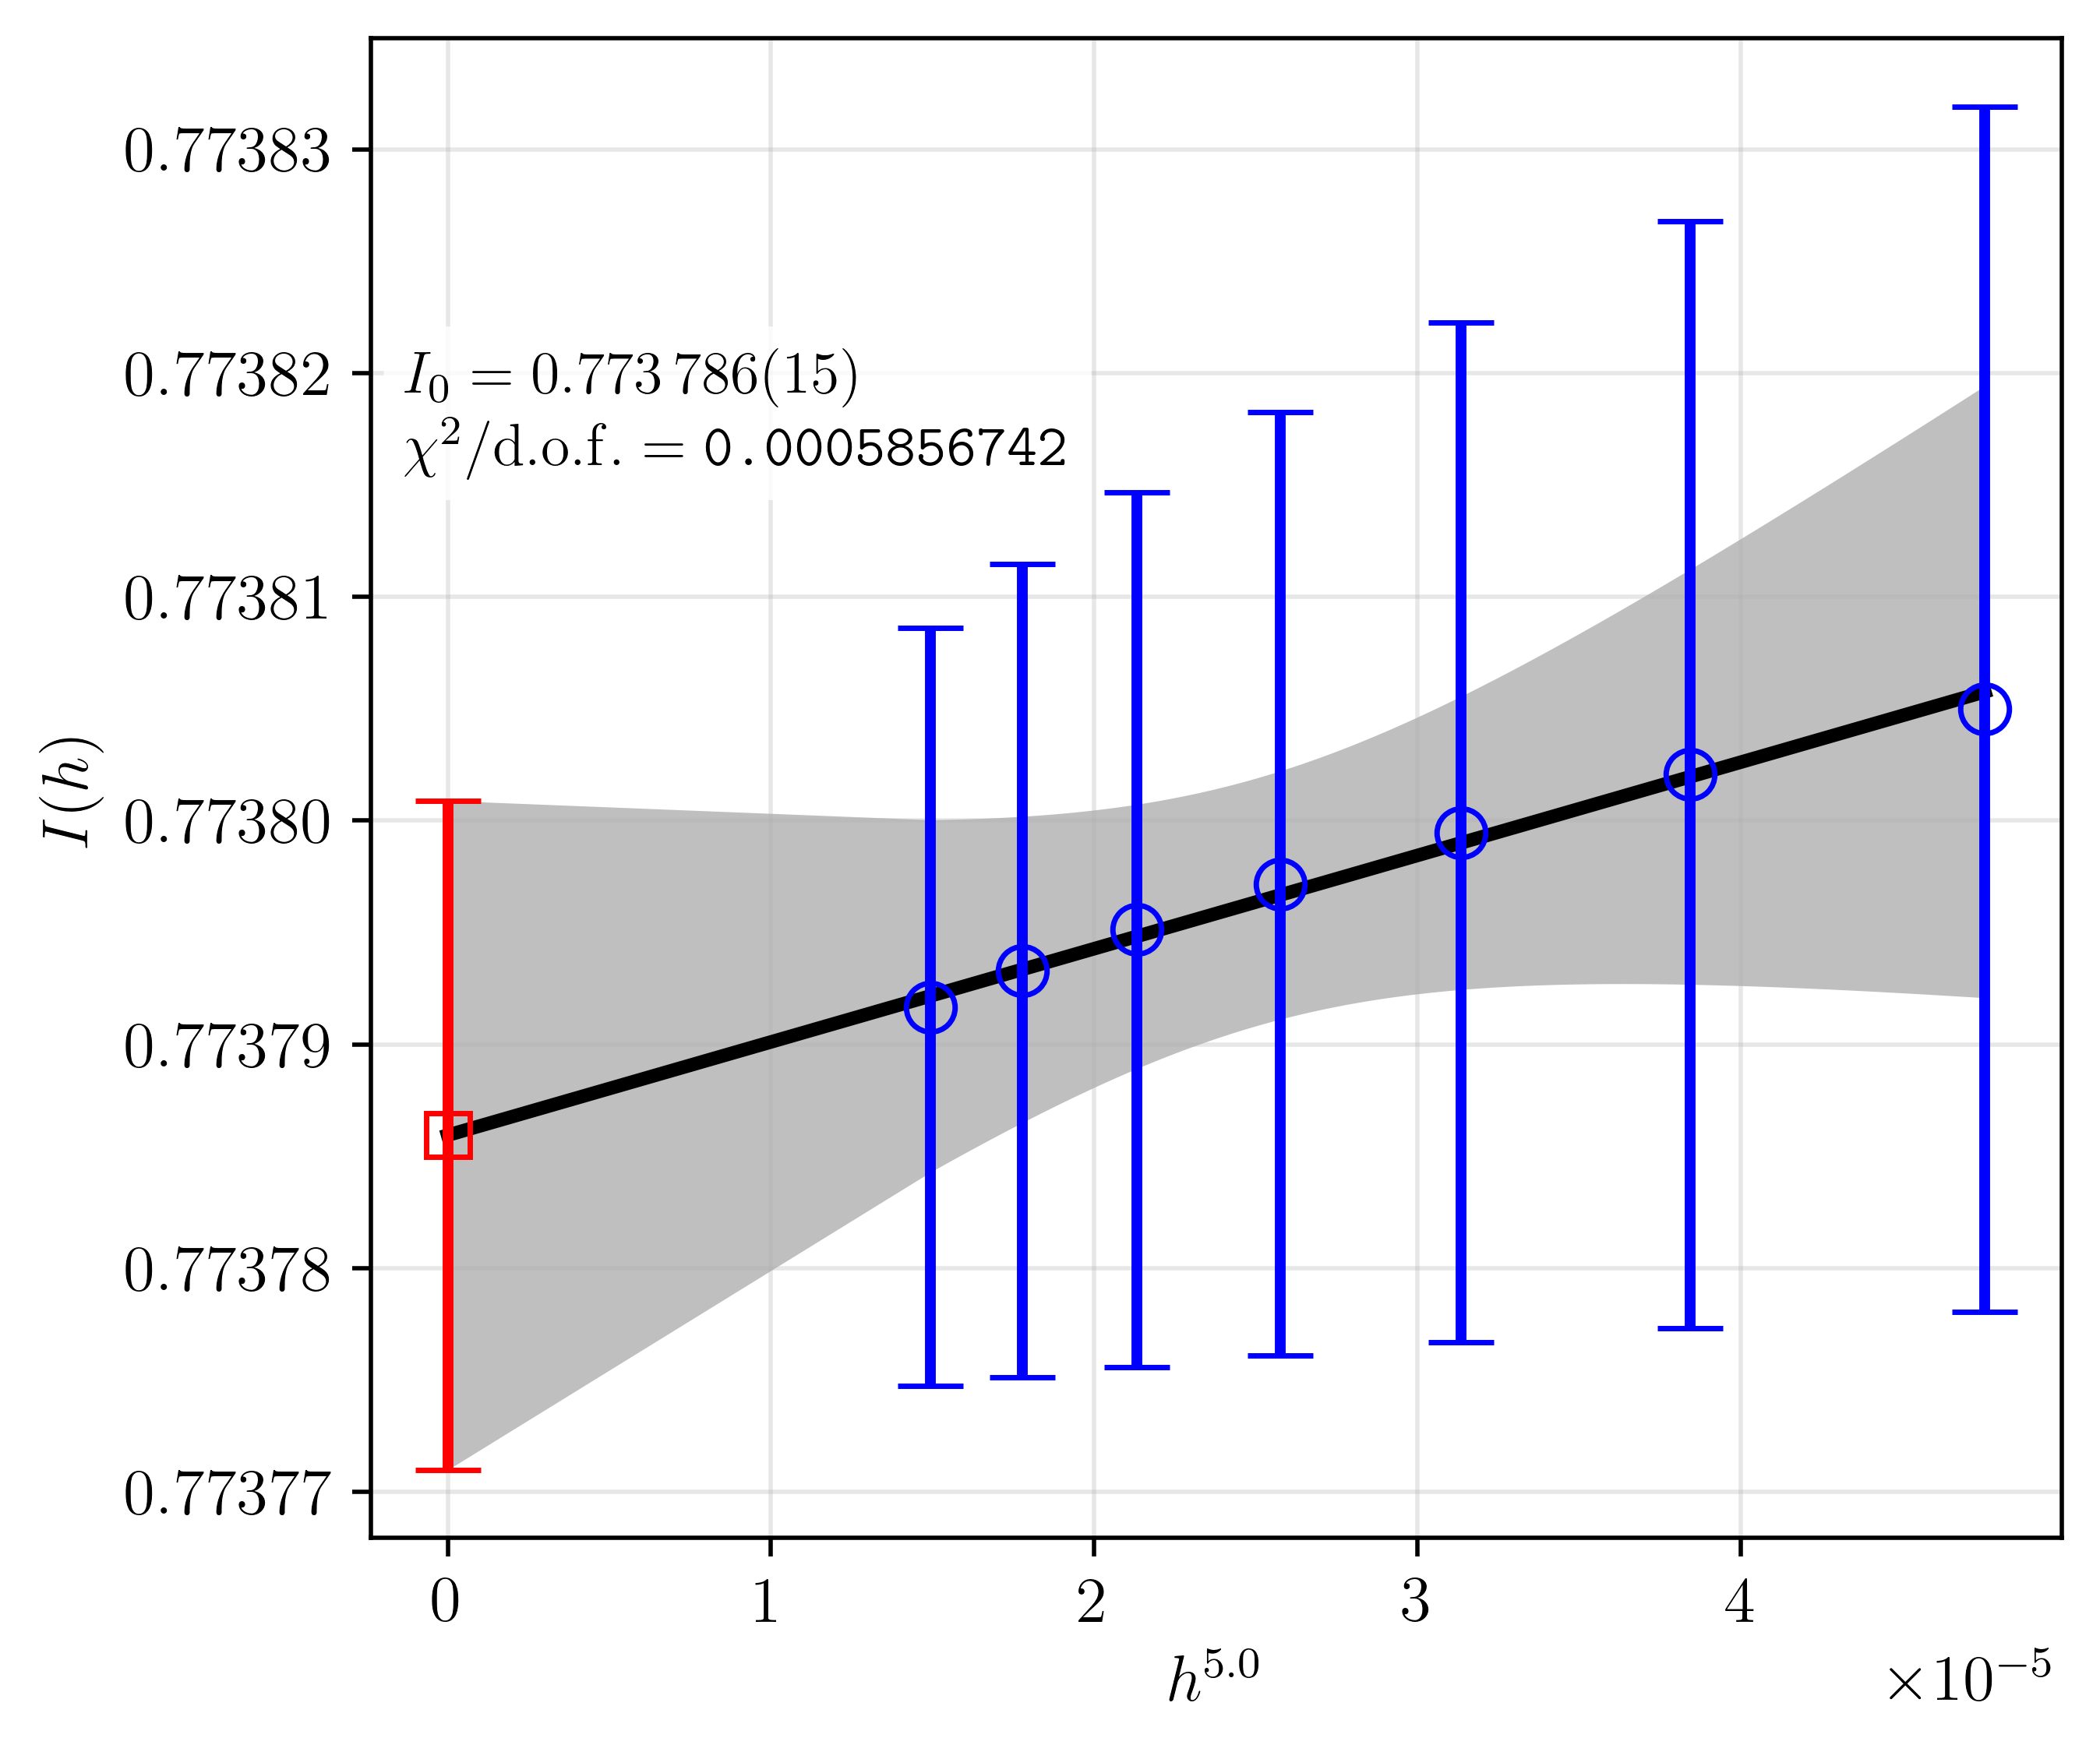

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_Z_q_gauss_p6_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `../samples/jld2/result_Z_q_gauss_p6_LU_EXEX_reldiff-crop.pdf'.


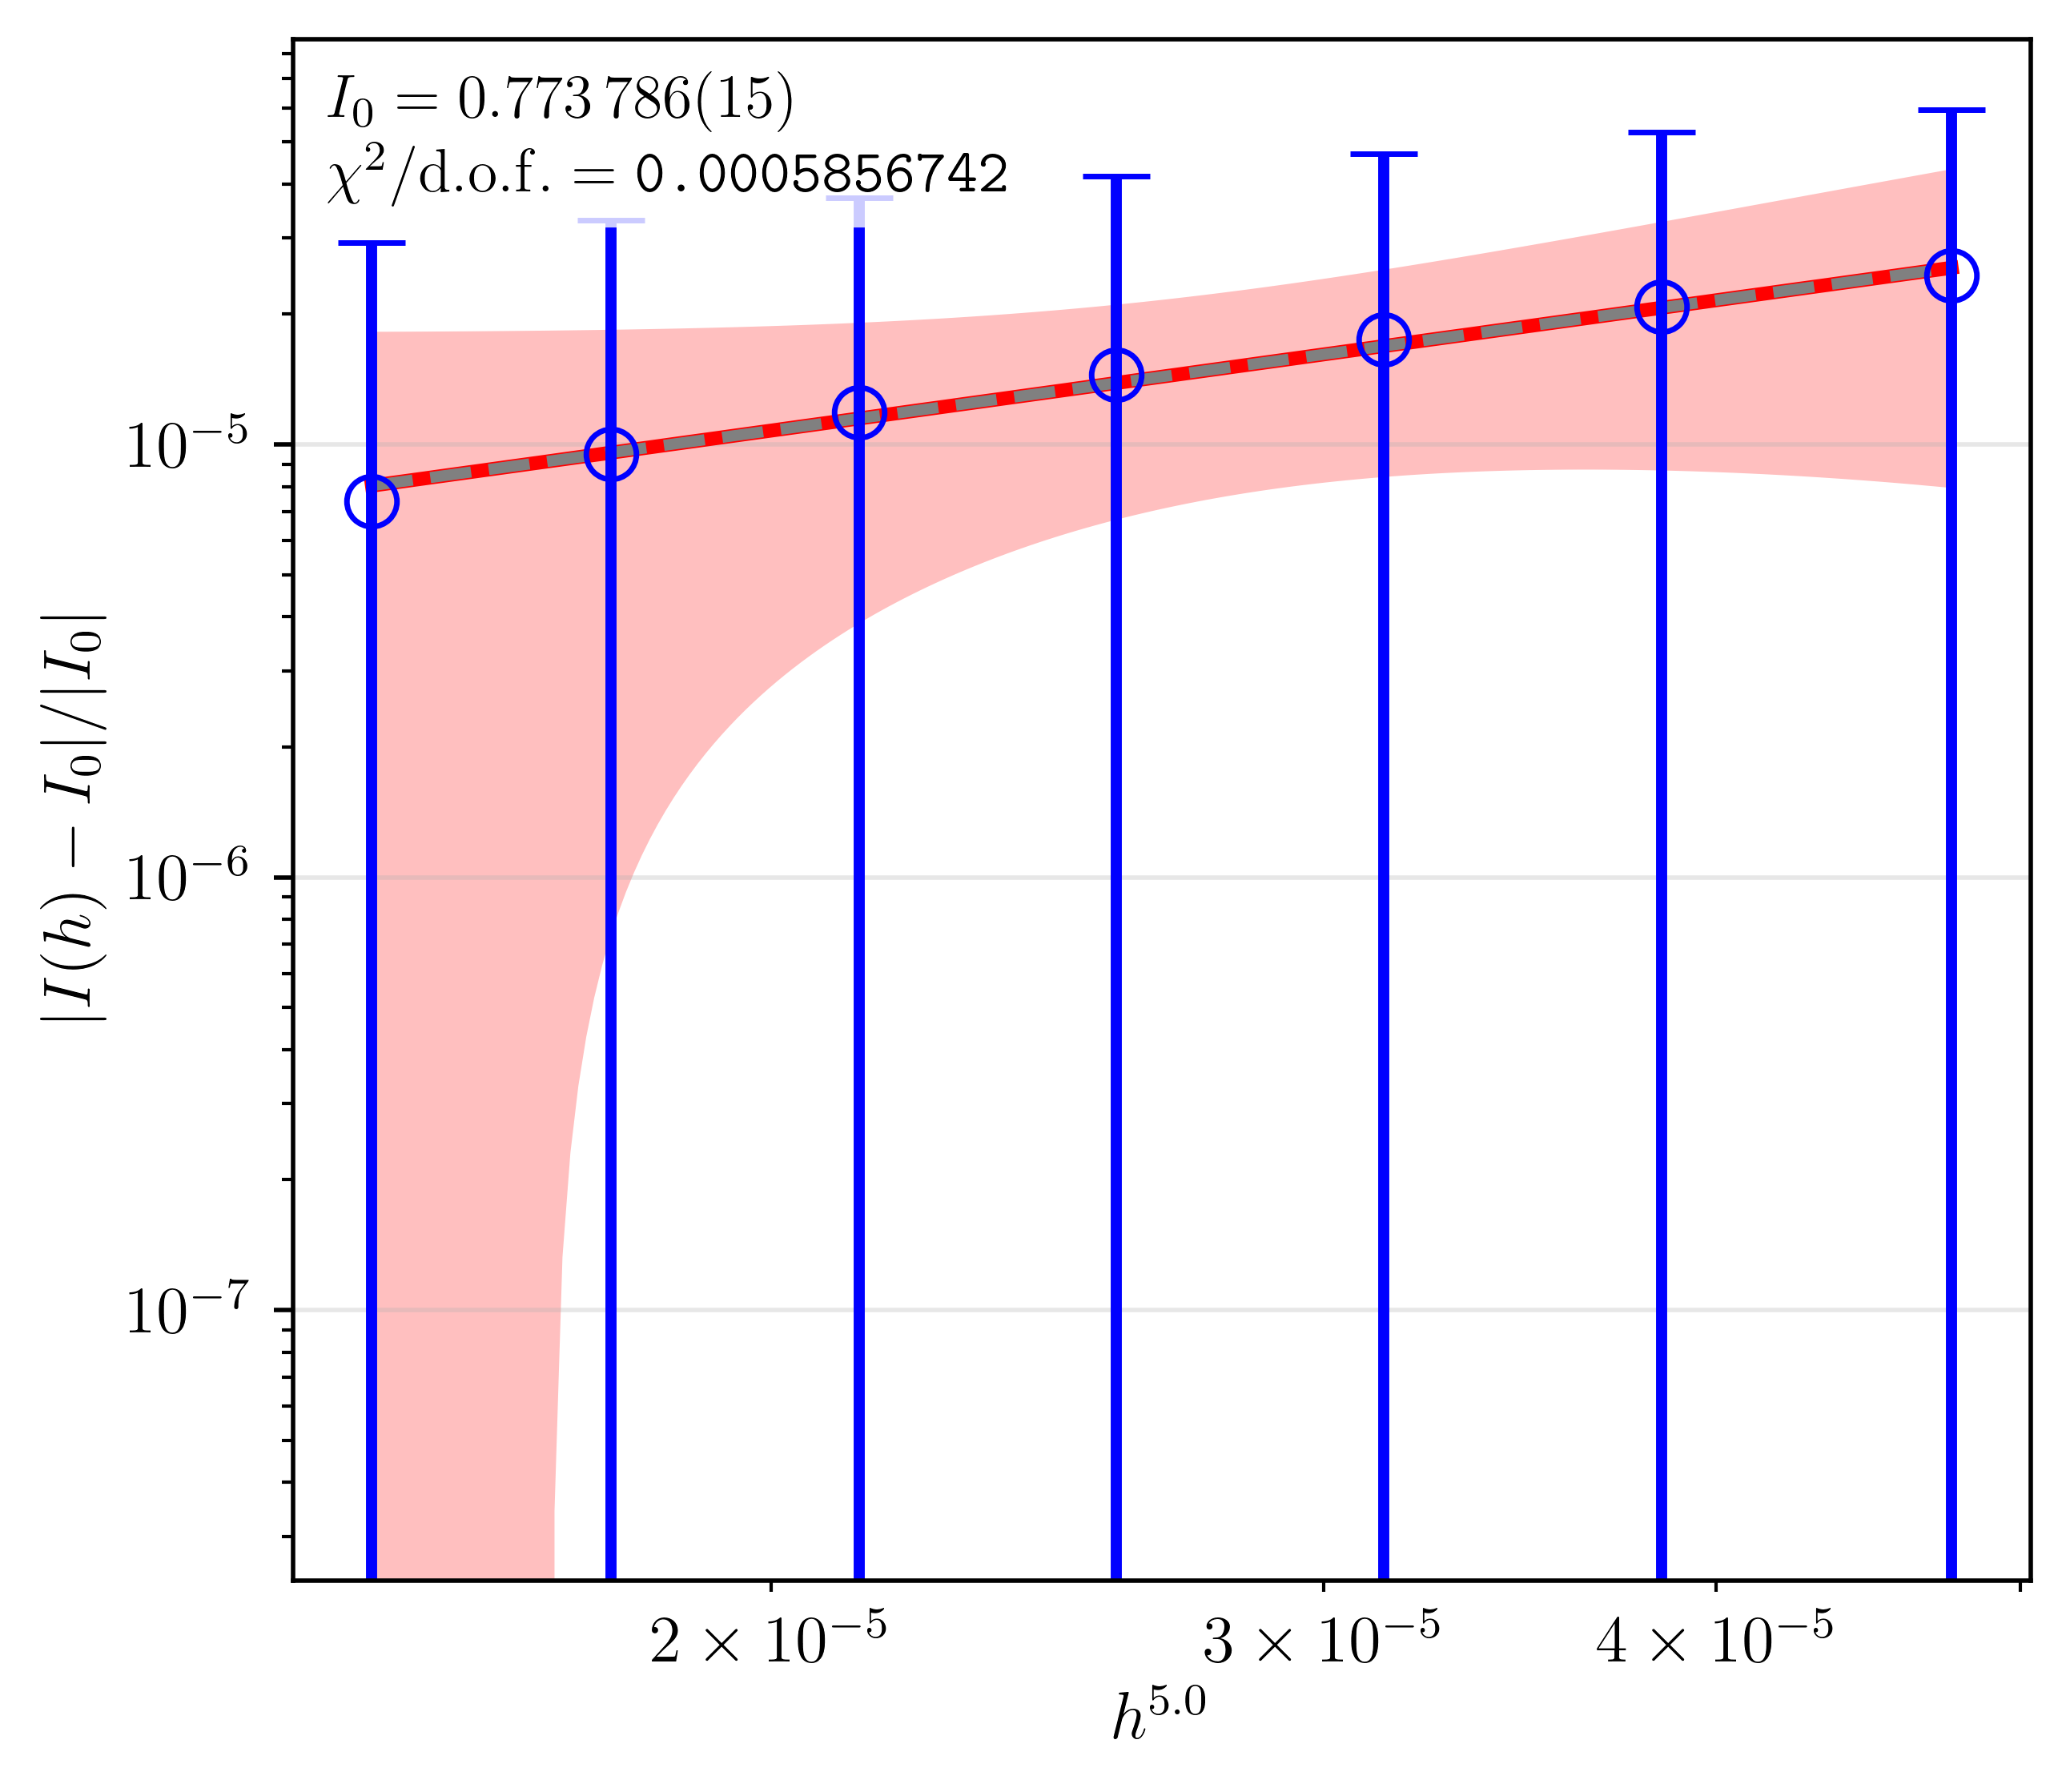

In [58]:
plot_convergence_result(
    run_result, 
    fit_result;
    name=result_string,
    figs_dir=save_path,
    save_file=true
)

## Generate the Final Fit-Aware Internal Note

Finally, we create a comprehensive report that includes:

- experiment configuration,
- datapoints,
- fitted parameters,
- uncertainty estimates,
- diagnostic plots.

This document serves as a complete record of the numerical study.

In [59]:
note_info = write_convergence_internal_note(
    run_result,
    fit_result;
    name = result_string,
    out_dir = save_path,
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
    nerr_terms=fit_nerr_terms,
    # author = "Benjamin J. Choi",
    # affiliation = "Center for Computational Sciences, University of Tsukuba, 1-1-1 Tennodai, Tsukuba, Ibaraki 305-8577, Japan",
    # abstract_text = "This note summarizes the convergence study and fitted extrapolation result."
)

pdflatex inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/home/benjamin/work.lib/texlive/2025/texmf-dist/tex/latex/revtex/aps12pt4-2.rt
x)
(/home/benjamin/work.l

(note_dir = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4", figs_dir = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/figs", summary_tex_path = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/summary_Z_q_gauss_p6_LU_EXEX_ff_4_table.tex", fig_tex_path = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/summary_Z_q_gauss_p6_LU_EXEX_ff_4_figs.tex", master_tex_path = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4.tex", makefile_path = "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/Makefile", moved_plots = ["../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/figs/result_Z_q_gauss_p6_LU_EXEX_extrap.pdf", "../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/figs/result_Z_q_gauss_p6_LU_EXEX_reldiff.pdf"], missing_plots = String[], build_attempted = true, build_succeeded = true, build_message = "Successfully built PDF via `make`: ../samples/jld2/inote_summary_Z_q_gauss_p6_LU_EXEX_ff_4/inote

## Summary

In this notebook we demonstrated a production-style workflow for
running a high-resolution quadrature study externally and analyzing the
results inside a Jupyter environment using `Maranatha.jl`.

Workflow:

1. Define the numerical experiment
2. Generate a standalone execution script
3. Run the computation externally with many threads
4. Load the saved result file
5. Inspect the raw convergence datapoints
6. Produce a datapoints-only internal note
7. Perform least-chi-square fitting
8. Visualize the fitted convergence behavior
9. Generate a final fit-aware report

This workflow is especially useful when:

- computations are too heavy for interactive execution,
- high thread counts or GPU resources are required,
- results must be reproducible outside the notebook,
- analysis and reporting are performed separately from production runs.

It reflects a practical research scenario where numerical data is
generated once and examined repeatedly using different analysis tools.